# Redes Neuronales Básicas con Python

## ¿Qué es una neurona artificial?

Una neurona artificial es un modelo matemático inspirado en las neuronas biológicas del cerebro.

Su función es:

- recibir datos de entrada
- procesarlos
- generar una salida

Las neuronas artificiales son la base de las redes neuronales y del Deep Learning.

---

# Componentes de una neurona

Una neurona tiene:

- entradas
- pesos
- bias
- función de activación
- salida

---

# Entradas

Las entradas son los datos que recibe la neurona.

Ejemplo:

```python
x1 = 1
x2 = 0
```

---

# Pesos

Los pesos indican la importancia de cada entrada.

Ejemplo:

```python
w1 = 0.5
w2 = -0.2
```

Si un peso es grande, esa entrada tiene mayor influencia.

---

# Bias

El bias ayuda a desplazar la decisión de la neurona.

Ejemplo:

```python
bias = -0.3
```

El bias permite ajustar mejor la clasificación.

---

# Suma ponderada

La neurona primero realiza una combinación lineal:

$$
z = w_1x_1 + w_2x_2 + b
$$

Donde:

- \(x\) = entradas
- \(w\) = pesos
- \(b\) = bias

---

# Función de activación

Después de calcular \(z\), la neurona aplica una función de activación.

La función de activación decide:

```markdown id="3ye4hn"
si la neurona se activa o no
```

---

# Activación tipo escalón

En este ejemplo usamos:

```python
def activation(z):
    return 1 if z >= 0 else 0
```

Representación matemática:

$$
f(z)=
\begin{cases}
1 & \text{si } z \ge 0 \\
0 & \text{si } z < 0
\end{cases}
$$

---

# ¿Para qué sirve la activación?

La activación permite:

- tomar decisiones
- clasificar datos
- convertir números en salidas binarias
- introducir no linealidad

Sin activación, la red solo haría operaciones matemáticas simples.

---

# ¿Qué es un perceptrón?

El perceptrón es la forma más básica de red neuronal.

Tiene:

- entradas
- una neurona
- una salida

---

# Objetivo del perceptrón

El perceptrón aprende automáticamente ajustando sus pesos para reducir errores.

---

# Aprendizaje del perceptrón

El proceso es:

1. calcular salida
2. comparar con el valor real
3. calcular error
4. ajustar pesos
5. repetir muchas veces

---

# Cálculo del error

El error se calcula así:

$$
error = y_{real} - y_{predicho}
$$

---

# Actualización de pesos

Cuando la neurona se equivoca, corrige los pesos.

La fórmula es:

$$
w_{nuevo} = w_{actual} + \eta(error)x
$$

Donde:

- (n) = learning rate
- error = diferencia entre valor real y predicción
- \(x\) = entrada
---

# Learning Rate

El learning rate controla qué tan rápido aprende la neurona.

Ejemplo:

```python
learning_rate = 0.1
```

- valores pequeños → aprendizaje lento
- valores grandes → aprendizaje rápido pero inestable

---

# Épocas

Una época es una repetición completa del entrenamiento usando todos los datos.

Ejemplo:

```python
epochs = 20
```

Mientras más épocas:

- más aprende la red
- pero también puede sobreajustarse

---

# Puerta lógica AND

Tabla AND:

| x1 | x2 | salida |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

La neurona debe aprender:

```markdown id="jlwmx9"
solo cuando ambas entradas son 1 la salida será 1
```

---

# Separación lineal

La puerta AND sí puede separarse usando una línea recta.

Por eso:

```markdown id="0r5j1c"
una sola neurona puede resolver AND
```


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df_and = pd.DataFrame({
    "x1": [0, 0, 1, 1],
    "x2": [0, 1, 0, 1],
    "y":  [0, 0, 0, 1]
})

df_and

,x1,x2,y
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []

    def activation(self, z):
        return 1 if z >= 0 else 0

    def fit(self, X, y):
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            total_error = 0

            for xi, target in zip(X, y):
                z = np.dot(xi, self.weights) + self.bias
                y_pred = self.activation(z)

                error = target - y_pred

                self.weights += self.lr * error * xi
                self.bias += self.lr * error

                total_error += abs(error)

            self.errors.append(total_error)

    def predict(self, X):
        predictions = []

        for xi in X:
            z = np.dot(xi, self.weights) + self.bias
            predictions.append(self.activation(z))

        return np.array(predictions)

In [ ]:
X_and = df_and[["x1", "x2"]].values
y_and = df_and["y"].values

model_and = Perceptron(learning_rate=0.1, epochs=20)
model_and.fit(X_and, y_and)

df_and["prediccion"] = model_and.predict(X_and)
df_and

,x1,x2,y,prediccion
0,0,0,0,0
1,0,1,0,0
2,1,0,0,0
3,1,1,1,1


In [ ]:
print("Pesos:", model_and.weights)
print("Bias:", model_and.bias)

Pesos: [0.2 0.1]
Bias: -0.20000000000000004


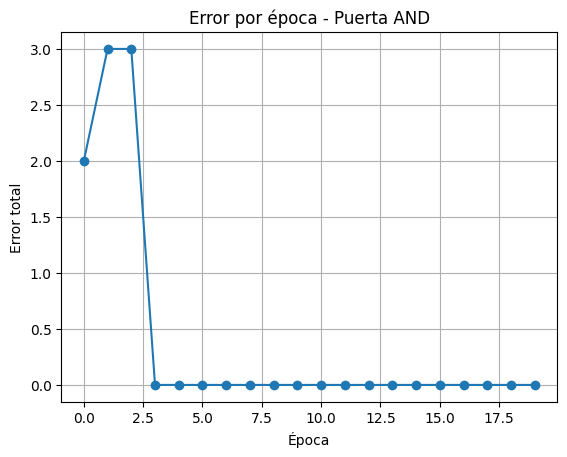

In [ ]:
plt.plot(model_and.errors, marker="o")
plt.title("Error por época - Puerta AND")
plt.xlabel("Época")
plt.ylabel("Error total")
plt.grid(True)
plt.show()

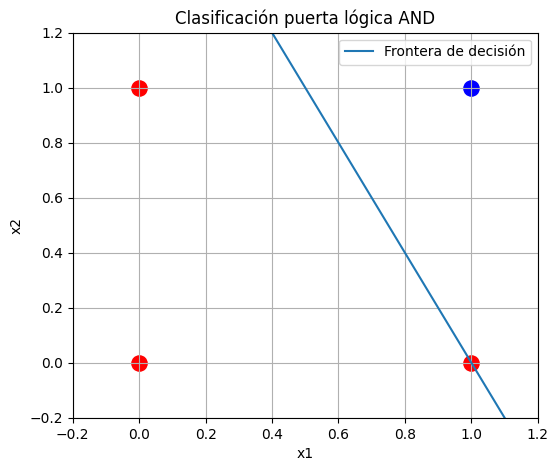

In [ ]:
plt.figure(figsize=(6, 5))

for i in range(len(df_and)):
    color = "red" if df_and["y"][i] == 0 else "blue"
    plt.scatter(df_and["x1"][i], df_and["x2"][i], color=color, s=120)

x_values = np.linspace(-0.2, 1.2, 100)

w1, w2 = model_and.weights
b = model_and.bias

# w1*x1 + w2*x2 + b = 0
# x2 = -(w1*x1 + b) / w2

y_values = -(w1 * x_values + b) / w2

plt.plot(x_values, y_values, label="Frontera de decisión")
plt.title("Clasificación puerta lógica AND")
plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.grid(True)
plt.legend()
plt.show()